In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import seaborn as sns

from funcs.simulation.interpolate import interpolate

In [2]:
HERE = Path().resolve()
DATA_DIR = HERE.parent / "simulation_measurement_comparison"
DB_PATH = DATA_DIR / "simulated_and_measured_2024-11-16_gri30_highT.sqlite"
H5_PATH = DB_PATH.with_suffix(".h5")

In [3]:
sim_meas = pd.read_hdf(H5_PATH, key="data_fixed_uncert")
sim_meas

,diluent,phi_nom,dil_mf_nom,p_0,u_p_0,t_0,phi,u_phi,dil_mf,u_dil_mf,...,u_wave_speed,cell_size_measured,u_cell_size_measured,cell_size_westbrook,cell_size_westbrook_2,gavrikov_criteria_met,znd_step,znd_end_time,znd_tries,znd_max_temp_time
0,CO2,0.4,0.10,101393.842884,2.307000,289.846188,0.419182,0.000208,0.103943,0.000040,...,1.212763,17.711596,2.065540,40.925134,364.312497,False,None,None,None,None
1,CO2,0.4,0.15,101400.200470,1.609842,290.021614,0.416662,0.000215,0.154795,0.000036,...,1.161985,26.122865,2.063038,76.639840,667.941320,False,None,None,None,None
2,CO2,0.4,0.20,101383.316513,1.976709,290.005443,0.425508,0.000378,0.207642,0.000063,...,1.326527,45.265852,7.552310,149.109836,1272.427132,False,None,None,None,None
3,CO2,0.7,0.10,101393.617108,2.121143,289.767941,0.735369,0.000243,0.104023,0.000045,...,1.446872,11.744907,2.280838,24.249279,225.067576,False,None,None,None,None
4,CO2,0.7,0.15,101412.528953,2.179424,289.308769,0.730354,0.000250,0.154600,0.000045,...,1.665023,14.199823,6.516796,43.235202,392.775812,False,None,None,None,None
5,CO2,0.7,0.20,101412.244820,1.938748,290.890143,0.739247,0.000282,0.207012,0.000045,...,1.251217,22.565446,2.059861,79.691460,708.046162,False,None,None,None,None
6,CO2,1.0,0.10,101396.288279,2.719599,290.170199,1.048230,0.000235,0.103722,0.000039,...,1.578345,10.729874,1.757072,19.634251,187.559489,False,None,None,None,None
7,CO2,1.0,0.15,101404.272743,1.800340,290.141360,1.048723,0.000231,0.154530,0.000037,...,1.479180,13.662187,2.065471,34.270648,320.188362,False,None,None,None,None
8,CO2,1.0,0.20,101410.128009,1.557379,290.441929,1.052847,0.000288,0.206571,0.000042,...,1.392106,18.601504,2.084832,62.552746,570.999400,False,None,None,None,None
9,N2,0.4,0.10,101368.606788,2.121188,289.359526,0.416727,0.000224,0.180426,0.000041,...,1.657319,15.263125,7.642898,24.847746,206.623224,False,None,None,None,None


In [23]:
with sqlite3.connect(DB_PATH) as con:
    bulk_properties = pd.read_sql_query(
        """
        select
            jcon.diluent,
            jcon.dil_condition,
            "time",
            (bp."time" / jcon.t_ind) progress,
            phi_nom,
            cp,
            cv,
            gamma
        from
            bulk_properties bp
        join (
            select
                *
            from
                conditions c
            join (
                select
                    condition_id,
                    max(run_no) mrn
                from
                    bulk_properties
                group by
                    condition_id
            ) maxes on
                c.id = maxes.condition_id
        ) jcon on
            bp.condition_id = jcon.condition_id
        where
            sim_type = 'cv'
            and mech = 'gri30_highT.yaml'
            and match = 'tad'
            and progress <= 1
            and bp.run_no = jcon.mrn
            and dil_condition != 'medium'
            and not phi_nom = 0.4
        order by
            diluent,
            dil_condition,
            phi_nom,
            progress
        ;
        """,
        con=con,
    )
interp_columns = ["cp", "cv", "gamma"]
bulk_properties_interp = interpolate(
    data=bulk_properties,
    time_column="progress",
    interp_columns=interp_columns,
    saturate=False,
    co2_label="CO2",
    n2_label="N2",
).reset_index(drop=True)
bulk_properties.head()

,diluent,dil_condition,time,progress,phi_nom,cp,cv,gamma
0,CO2,high,0.000000e+00,0.000000,0.7,1569.164267,1364.134482,1.150300
1,CO2,high,8.185803e-09,0.000565,0.7,1569.157368,1364.125640,1.150303
2,CO2,high,1.637161e-08,0.001130,0.7,1569.149755,1364.116086,1.150305
3,CO2,high,2.455741e-08,0.001695,0.7,1569.142105,1364.106496,1.150308
4,CO2,high,3.988625e-08,0.002753,0.7,1569.127973,1364.088745,1.150312


In [24]:
def calculate_co2_n2_ratios(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    co2_diluted = data[data["diluent"] == "CO2"].set_index(["dil_condition", "phi_nom"]).drop("diluent", axis=1)
    n2_diluted = data[data["diluent"] == "N2"].set_index(["dil_condition", "phi_nom"]).drop("diluent", axis=1)
    for column in columns:
        co2_diluted.loc[:, column] = co2_diluted[column] / n2_diluted[column]
    return co2_diluted

ratios = calculate_co2_n2_ratios(bulk_properties_interp, interp_columns).reset_index()

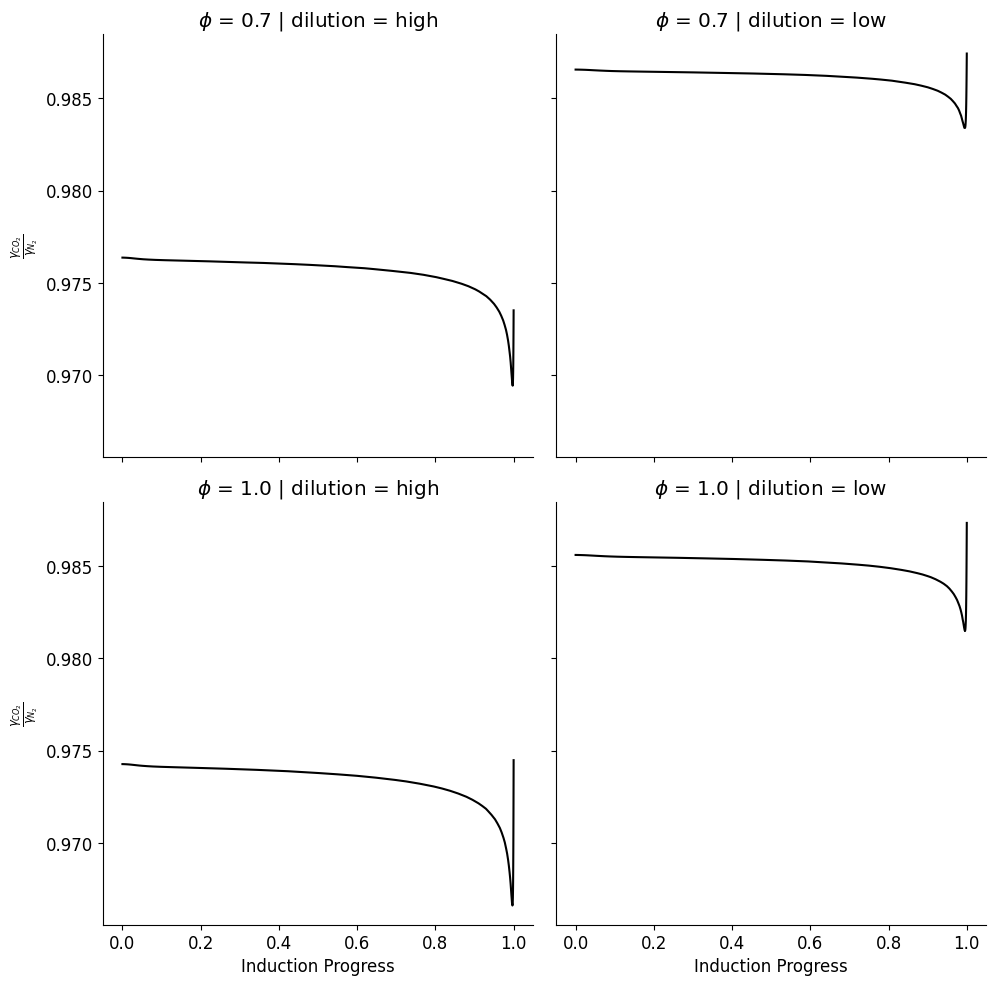

In [19]:
grid = sns.relplot(
    x="progress",
    y="gamma",
    data=ratios,
    col="dil_condition",
    row="phi_nom",
    kind="line",
    color="k",
)
for ax in grid.axes.flatten():
    ax.set_ylabel(r"$\frac{\gamma_{CO_{2}}}{\gamma_{N_{2}}}$")
    ax.set_xlabel("Induction Progress")
    ax.set_title(ax.get_title().replace("phi_nom", r"$\phi$").replace("dil_condition", "dilution"))

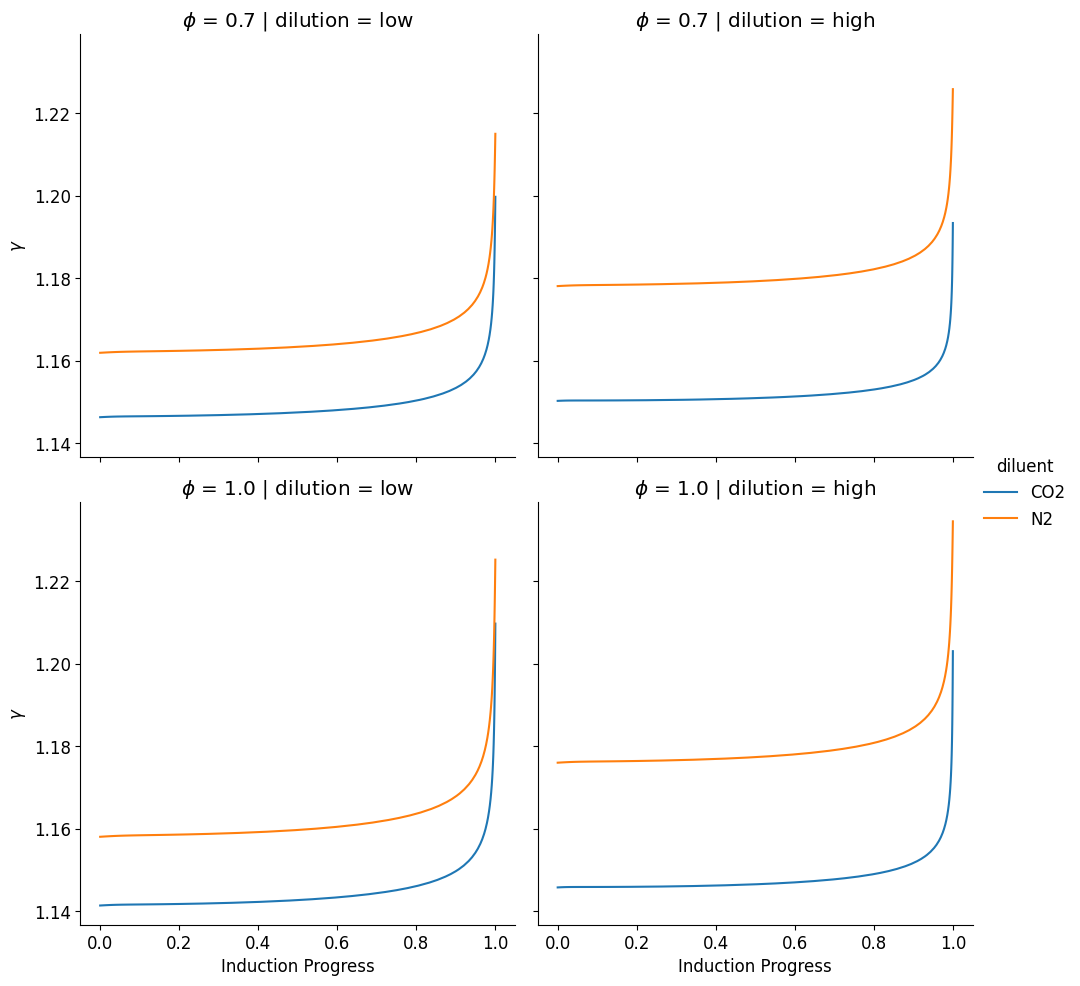

In [29]:
grid = sns.relplot(
    x="progress",
    y="gamma",
    data=bulk_properties,
    col="dil_condition",
    row="phi_nom",
    hue="diluent",
    kind="line",
    col_order=["low", "high"],
)
for ax in grid.axes.flatten():
    ax.set_ylabel(r"$\gamma$")
    ax.set_xlabel("Induction Progress")
    ax.set_title(ax.get_title().replace("phi_nom", r"$\phi$").replace("dil_condition", "dilution"))

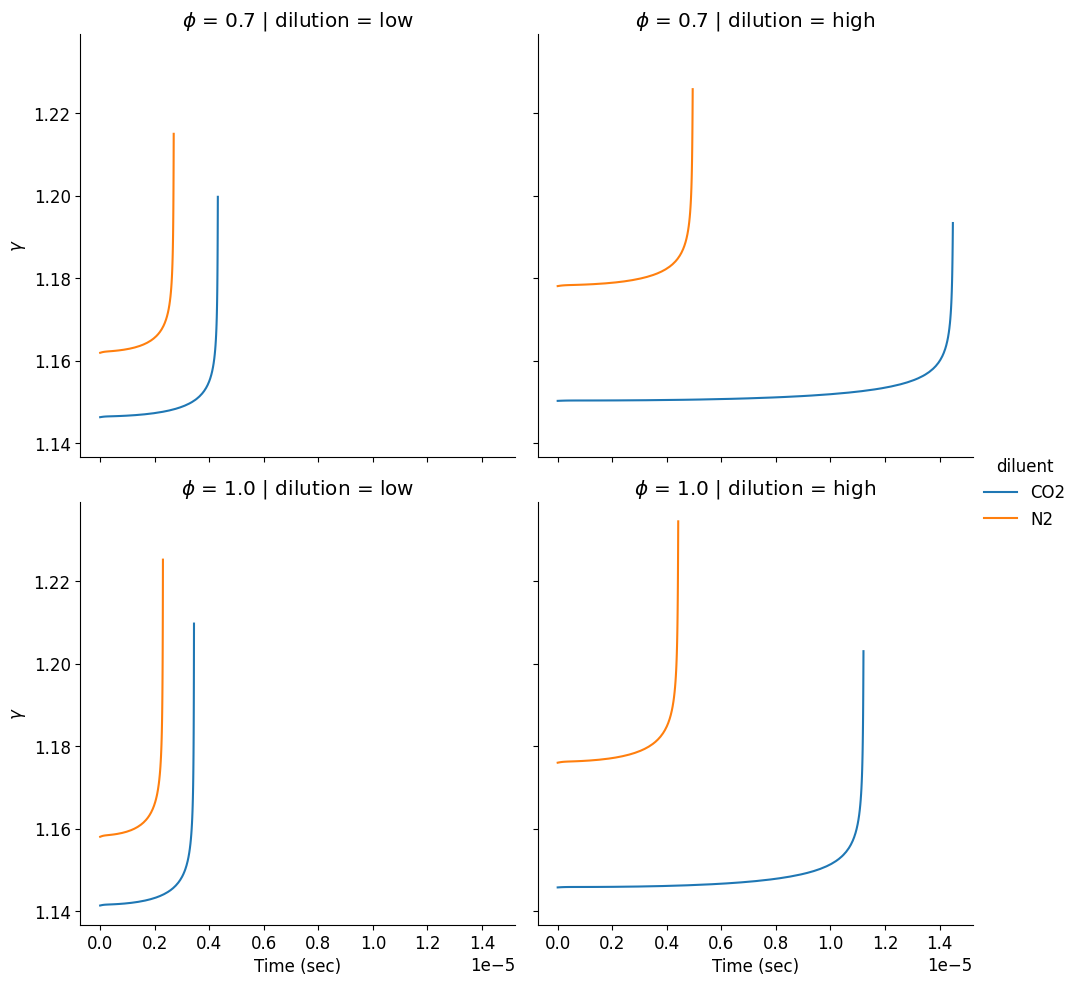

In [30]:
grid = sns.relplot(
    x="time",
    y="gamma",
    data=bulk_properties,
    col="dil_condition",
    row="phi_nom",
    hue="diluent",
    kind="line",
    col_order=["low", "high"],
)
for ax in grid.axes.flatten():
    ax.set_ylabel(r"$\gamma$")
    ax.set_xlabel("Time (sec)")
    ax.set_title(ax.get_title().replace("phi_nom", r"$\phi$").replace("dil_condition", "dilution"))